In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns

In [3]:
data = {
    "YearsExperience": [
        1.1, 1.3, 1.5, 2.0, 2.2,
        2.9, 3.0, 3.2, 3.7, 3.9,
        4.0, 4.5, 4.9, 5.1, 5.3,
        5.9, 6.0, 6.8, 7.1, 7.9,
        8.2, 8.7, 9.0, 9.5, 10.3
    ],

    "Salary": [
        39343, 46205, 37731, 43525, 39891,
        56642, 60150, 54445, 57189, 63218,
        55794, 61111, 67938, 66029, 83088,
        81363, 93940, 91738, 98273, 101302,
        113812, 109431, 105582, 116969, 122391
    ]
}

In [4]:
df = pd.DataFrame(data)

In [5]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [6]:
X=df[["YearsExperience"]]
y=df["Salary"]

In [7]:
y


0      39343
1      46205
2      37731
3      43525
4      39891
5      56642
6      60150
7      54445
8      57189
9      63218
10     55794
11     61111
12     67938
13     66029
14     83088
15     81363
16     93940
17     91738
18     98273
19    101302
20    113812
21    109431
22    105582
23    116969
24    122391
Name: Salary, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train

,YearsExperience
9,3.9
13,5.1
1,1.3
22,9.0
5,2.9
2,1.5
12,4.9
15,5.9
3,2.0
4,2.2


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [11]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [13]:
regression = LinearRegression()
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
mse = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=5)

In [15]:
np.mean(mse)

np.float64(-33262409.429427914)

In [16]:
reg = regression.predict(X_test)

In [17]:
reg

array([ 60902.43255768,  82996.55935038,  35926.46313984, 116618.05664361,
        68587.3462247 ])

C:\Users\abhin\AppData\Local\Temp\ipykernel_5540\1756589244.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(reg-y_test)


<Axes: xlabel='Salary', ylabel='Density'>

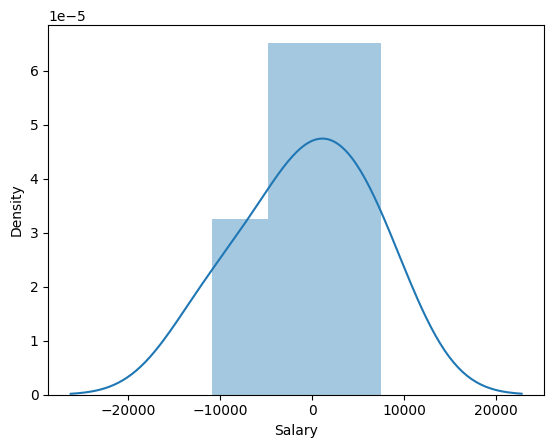

In [21]:
sns.distplot(reg-y_test)